In [1]:
using Revise
using SSMCMain.ModifiedMiCRM.MinimalModelV2

In [2]:
includet("../../scripts/mm_Kl_pds.jl")

In [3]:
using ProgressMeter
using ColorSchemes
using JLD2

In [4]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Main

In [39]:
logKs = range(-0.5, 3, 50)
lmin = 0.001
lmax = 1 - lmin
numls = 50

m = 1.
c = 1.
p = 1

ks = 10 .^ range(-6, 4, 10000)

leakxs = range(LeakageScale.ltox(lmin), LeakageScale.ltox(lmax), numls)
ls = LeakageScale.l.(leakxs)
Ks = 10 .^ logKs

# @time pd_results = do_Kl_pd_run(
#     logKs, ls,
#     m, c,
#     0., 1., p,
# );
@time pd_results = do_Kl_pd_run_scanning(
    ks,
    logKs, ls,
    m, c,
    # 0.0, 1., p;
    1e-6, 1., p;
    threshold=1e-9
);

  7.002129 seconds (223.10 M allocations: 29.036 GiB, 43.11% gc time)


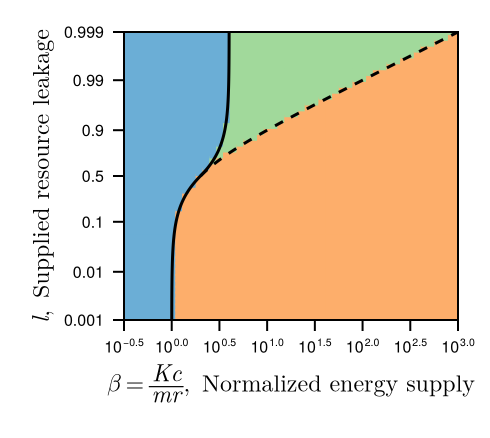

In [16]:
lticks=[0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999]

fig = Figure(;
    size=(double_col_width * 0.36, (double_col_width / golden_ratio) * 0.52),
)
ax = Axis(fig[1,1],
    yticks=(LeakageScale.ltox.(lticks), string.(lticks)),
    xscale=log10,
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    # xlabel=L"K,\enspace\text{Resource supply rate}",
    ylabel=L"l,\enspace\text{Supplied resource leakage}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

heatmap!(ax, Ks, leakxs, PaperColors.mma_coloring_simple.(pd_results))

thr_leakxs = range(extrema(leakxs)..., 1000)
thr_ls = LeakageScale.l.(thr_leakxs)

extline_Ks = MinimalModelV2.fr_ext_line_K.(thr_ls, 1., 1.)
instabline_Ks = MinimalModelV2.fr_cor1_instab_line_K.(thr_ls, 1., 1., p)

lines!(ax, extline_Ks, thr_leakxs;
    color=:black,
)
lines!(ax, instabline_Ks, thr_leakxs;
    color=:black,
    linestyle=:dash,
)

xlims!(ax, extrema(Ks))
ylims!(ax, extrema(leakxs))

Makie.save("../../data/mm_phase_diagrams/DN0.pdf", fig)

fig

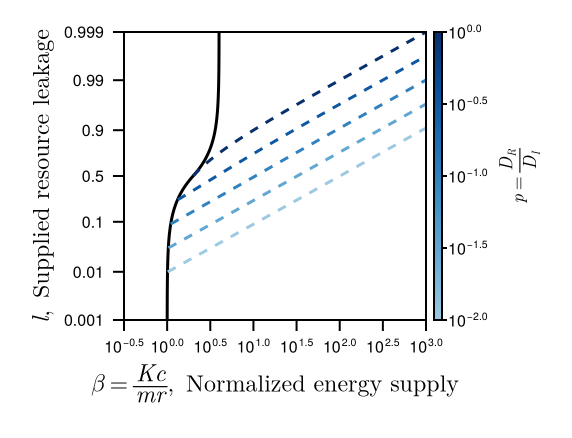

In [6]:
lticks=[0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999]

fig = Figure(;
    size=(double_col_width * 0.42, (double_col_width / golden_ratio) * 0.52),
)
ax = Axis(fig[1:2,1],
    yticks=(LeakageScale.ltox.(lticks), string.(lticks)),
    xscale=log10,
    # xlabel=L"K,\enspace\text{Resource supply rate}",
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    ylabel=L"l,\enspace\text{Supplied resource leakage}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
    xgridvisible=false,
    ygridvisible=false,
)

thr_leakxs = range(extrema(leakxs)..., 1000)
thr_ls = LeakageScale.l.(thr_leakxs)

extline_Ks = MinimalModelV2.fr_ext_line_K.(thr_ls, 1., 1.)

lines!(ax, extline_Ks, thr_leakxs;
    color=:black,
)

logps = range(0., -2, 5)
ps = 10 .^ logps
ps_cmap = cgrad(ColorSchemes.Blues[4:end])

lalal = extrema(logps)
logps_delta = lalal[2] - lalal[1]
logps_min = lalal[1]

for logp in logps
    p_ = 10 ^ logp
    instabline_Ks = MinimalModelV2.fr_cor1_instab_line_K.(thr_ls, 1., 1., p_)
    lines!(ax, instabline_Ks, thr_leakxs;
        color=get(ps_cmap, (logp - logps_min) / logps_delta),
        linestyle=:dash,
    )
end

xlims!(ax, extrema(Ks))
ylims!(ax, extrema(leakxs))

Colorbar(fig[1:2,2];
    limits=extrema(ps),
    colormap=ps_cmap,
    scale=log10,
    size=4,
    ticklabelsize=6fontsize_pt,
    labelsize=6fontsize_ltex_pt,
    label=L"p=\frac{D_R}{D_I}",
    ticksize=2,
    ticklabelpad=0,
)
# Label(fig[1,2], L"p=\frac{D_R}{D_I}";
#     rotation=pi/2,
# )

colgap!(fig.layout, 4.)
# rowsize!(fig.layout, 2, Relative(0.8))

Makie.save("../../figures/fig2_mm_when/changing_p.pdf", fig)

fig

# Funky things

In [64]:
ls_to_sample = 29:7:length(ls)
# ls_to_sample = [length(ls)]
display([ls[x] for x in ls_to_sample])
Kis_to_sample = []

for i in ls_to_sample
    first_unstable = nothing
    last_unstable = nothing
    for j in 1:length(logKs)
        if isnothing(first_unstable) && (pd_results[j, i] != 0)
            first_unstable = j
        end
        if isnothing(last_unstable) && (pd_results[j, i] == 2)
            last_unstable = j - 1
        end
    end

    step = round(Int, (last_unstable - first_unstable) / 4)
    push!(Kis_to_sample, [first_unstable, first_unstable + step, first_unstable + 2 * step, first_unstable + 3 * step, last_unstable])
end

4-element Vector{Float64}:
 0.7284315141008784
 0.9507357626281727
 0.9928494961887867
 0.999

In [65]:
Kls = []
for (l_i, K_is) in zip(ls_to_sample, Kis_to_sample)
    l = ls[l_i]
    for Ki in K_is
        K = 10 ^ logKs[Ki]
        push!(Kls, (K, l))
    end
end
Kls

20-element Vector{Any}:
 (3.1622776601683795, 0.7284315141008784)
 (3.1622776601683795, 0.7284315141008784)
 (3.1622776601683795, 0.7284315141008784)
 (3.1622776601683795, 0.7284315141008784)
 (3.1622776601683795, 0.7284315141008784)
 (4.393970560760792, 0.9507357626281727)
 (6.1054022965853285, 0.9507357626281727)
 (8.48342898244072, 0.9507357626281727)
 (11.787686347935873, 0.9507357626281727)
 (19.306977288832506, 0.9507357626281727)
 (4.393970560760792, 0.9928494961887867)
 (10.0, 0.9928494961887867)
 (22.758459260747887, 0.9928494961887867)
 (51.7947467923121, 0.9928494961887867)
 (138.94954943731375, 0.9928494961887867)
 (4.393970560760792, 0.999)
 (16.378937069540637, 0.999)
 (61.0540229658533, 0.999)
 (227.58459260747887, 0.999)
 (848.3428982440716, 0.999)